<a href="https://colab.research.google.com/github/lucid005/AI-and-Machine-Learning/blob/main/2408619_SauravShrestha_NLP_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Racist/Sexist Tweet Classification using RNN, LSTM, and Pretrained Embeddings

**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Assessment:** Final Portfolio - Part III NLP Task  
**Dataset:** Racist Sexist or Not Dataset  
**Student Name:** Saurav Shrestha  
**Student ID:** 2408619  

This notebook completes the NLP portfolio task for binary tweet classification. The goal is to classify tweets into:

- `0`: not racist/sexist
- `1`: racist/sexist

## 1. Project Setup

This section prepares the NLP workflow by locating the dataset, importing the required libraries, and creating output folders. The notebook was run in Google Colab from Google Drive. No GPU device was detected, so all training was completed on CPU. This matters for interpretation because the reported training times reflect a CPU-based run rather than accelerated training.

In [ ]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

candidate_dataset_paths = [
    Path("/content/drive/MyDrive/AI&ML/NLP Task/Racist Sexist or Not Dataset"),
]

DATASET_PATH = next((path for path in candidate_dataset_paths if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        "Dataset folder was not found. Update DATASET_PATH to the folder containing train_racisit.csv and test_racisit.csv."
    )

TRAIN_CSV = DATASET_PATH / "train_racisit.csv"
TEST_CSV = DATASET_PATH / "test_racisit.csv"

if "drive" in str(DATASET_PATH):
    PROJECT_ROOT = DATASET_PATH.parent
else:
    PROJECT_ROOT = Path.cwd().parent

OUTPUT_DIR = PROJECT_ROOT / "portfolio_outputs" / "nlp_hate_speech"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATASET_PATH)
print("Output path:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/AI&ML/NLP Task/Racist Sexist or Not Dataset
Output path: /content/drive/MyDrive/AI&ML/NLP Task/portfolio_outputs/nlp_hate_speech


In [ ]:
import os
import re
import random
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import contractions

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_colwidth", 160)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: []


In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


## 2. Load and Understand the Dataset

The dataset contains labelled tweets for binary classification. Label `0` means the tweet is not racist/sexist, while label `1` means the tweet is racist/sexist. The provided external test file does not contain labels, so it is used only for final predictions. For model evaluation, the labelled training file is split into a stratified training and held-out test set.

The labelled file contains 31,962 tweets. The class distribution is strongly imbalanced: 29,720 tweets are labelled `0` and 2,242 tweets are labelled `1`. This means only 7.01% of labelled tweets belong to the racist/sexist class. Because of that imbalance, accuracy alone is not enough to judge the models; precision, recall, F1-score, and confusion matrices are also required.

In [ ]:
def read_csv_with_fallback(path):
    encodings = ["utf-8", "latin1", "cp1252"]
    last_error = None
    for encoding in encodings:
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError as error:
            last_error = error
    raise last_error


train_df = read_csv_with_fallback(TRAIN_CSV)
external_test_df = read_csv_with_fallback(TEST_CSV)

print("Training shape:", train_df.shape)
print("External test shape:", external_test_df.shape)
display(train_df.head())
display(external_test_df.head())

Training shape: (31962, 3)
External test shape: (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
1,2,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦
4,5,0,factsguide: society now #motivation


,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedication #willpower to find #newmaterialsâ¦
1,31964,@user #white #supremacists want everyone to see the new â #birdsâ #movie â and hereâs why
2,31965,safe ways to heal your #acne!! #altwaystoheal #healthy #healing!!
3,31966,"is the hp and the cursed child book up for reservations already? if yes, where? if no, when? ððð #harrypotter #pottermore #favorite"
4,31967,"3rd #bihday to my amazing, hilarious #nephew eli ahmir! uncle dave loves you and missesâ¦"


Training columns: ['id', 'label', 'tweet']
External test columns: ['id', 'tweet']
Missing values in training data:


,0
id,0
label,0
tweet,0


,count,percent
label,,
0,29720,92.99
1,2242,7.01


/tmp/ipykernel_3901/3452101915.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Label")


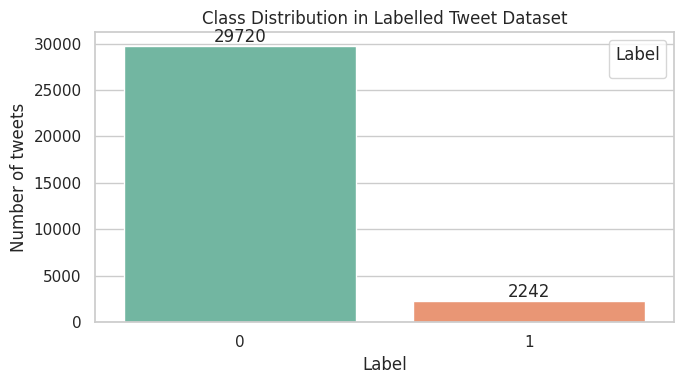

Positive class rate: 7.01%
Unique training tweets: 29530 / 31962


In [ ]:
print("Training columns:", train_df.columns.tolist())
print("External test columns:", external_test_df.columns.tolist())

missing_summary = train_df[["id", "label", "tweet"]].isna().sum()
print("Missing values in training data:")
display(missing_summary)

label_counts = train_df["label"].value_counts().sort_index()
label_percent = (label_counts / len(train_df) * 100).round(2)
label_summary = pd.DataFrame({"count": label_counts, "percent": label_percent})
display(label_summary)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=label_summary.index.astype(str), y=label_summary["count"], hue=label_summary.index.astype(str))
ax.set_title("Class Distribution in Labelled Tweet Dataset")
ax.set_xlabel("Label")
ax.set_ylabel("Number of tweets")
ax.legend(title="Label")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=160)
plt.show()

positive_rate = train_df["label"].mean() * 100
print(f"Positive class rate: {positive_rate:.2f}%")
print(f"Unique training tweets: {train_df['tweet'].nunique()} / {len(train_df)}")

,raw_char_length,raw_word_length
count,31962.00,31962.00
mean,84.74,13.16
std,29.46,5.48
min,11.00,3.00
25%,63.00,9.00
50%,88.00,13.00
75%,108.00,17.00
max,274.00,34.00


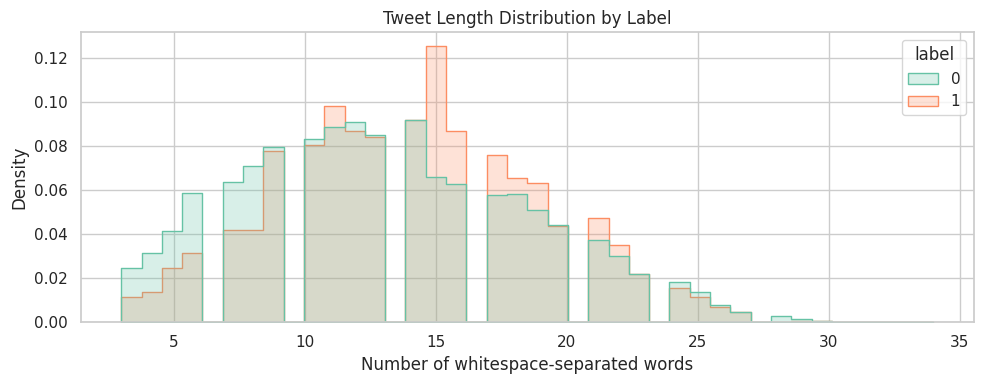

In [ ]:
train_df["raw_char_length"] = train_df["tweet"].astype(str).str.len()
train_df["raw_word_length"] = train_df["tweet"].astype(str).str.split().str.len()

display(train_df[["raw_char_length", "raw_word_length"]].describe().round(2))

plt.figure(figsize=(10, 4))
sns.histplot(data=train_df, x="raw_word_length", hue="label", bins=40, element="step", stat="density", common_norm=False)
plt.title("Tweet Length Distribution by Label")
plt.xlabel("Number of whitespace-separated words")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "tweet_length_distribution.png", dpi=160)
plt.show()

## 3. Text Cleaning and Preprocessing

The raw tweets contain mentions, hashtags, URLs, contractions, encoding artifacts, punctuation, numbers, emojis, and informal social media language. The cleaning pipeline lowercases text, repairs common encoding artifacts, expands contractions, removes URLs and mentions, removes numbers and special characters, removes stopwords, and lemmatizes words.

Hashtags are handled by removing the `#` symbol while keeping the hashtag word. This is important because hashtag words can contain useful meaning for classification. After cleaning, 40 training tweets and 28 external test tweets became empty, which is expected for very short tweets that mostly contain mentions, symbols, or stopwords.

In [ ]:
def fix_mojibake(text):
    # Try to repair common latin1/utf-8 mojibake from CSV imports.
    text = str(text)
    try:
        repaired = text.encode("latin1").decode("utf-8")
        if "\u00c3" in text or "\u00f0" in text or "\u00e2" in text:
            return repaired
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    return text


def clean_tweet(text):
    text = fix_mojibake(text)
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for token in text.split():
        if token not in STOP_WORDS and len(token) > 1:
            tokens.append(LEMMATIZER.lemmatize(token))
    return " ".join(tokens)


train_df["clean_tweet"] = train_df["tweet"].apply(clean_tweet)
external_test_df["clean_tweet"] = external_test_df["tweet"].apply(clean_tweet)

display(train_df[["tweet", "clean_tweet", "label"]].head(10))
print("Empty cleaned training tweets:", (train_df["clean_tweet"].str.len() == 0).sum())
print("Empty cleaned external test tweets:", (external_test_df["clean_tweet"].str.len() == 0).sum())

,tweet,clean_tweet,label
0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,father dysfunctional selfish drag kid dysfunction run,0
1,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,thanks lyft credit cannot use offer wheelchair van pdx disapointed getthanked,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦,model love take time,0
4,factsguide: society now #motivation,factsguide society motivation,0
5,[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo,huge fan fare big talking leave chaos pay dispute get allshowandnogo,0
6,@user camping tomorrow @user @user @user @user @user @user @user dannyâ¦,camping tomorrow danny,0
7,the next school year is the year for exams.ð¯ can't think about that ð­ #school #exams #hate #imagine #actorslife #revolutionschool #girl,next school year year exam cannot think school exam hate imagine actorslife revolutionschool girl,0
8,we won!!! love the land!!! #allin #cavs #champions #cleveland #clevelandcavaliers â¦,love land allin cavs champion cleveland clevelandcavaliers,0
9,@user @user welcome here ! i'm it's so #gr8 !,welcome gr,0


Empty cleaned training tweets: 40
Empty cleaned external test tweets: 28


,word,count
0,day,2923
1,love,2898
2,amp,1777
3,happy,1707
4,life,1268
5,time,1262
6,like,1222
7,today,1106
8,get,1003
9,new,1003


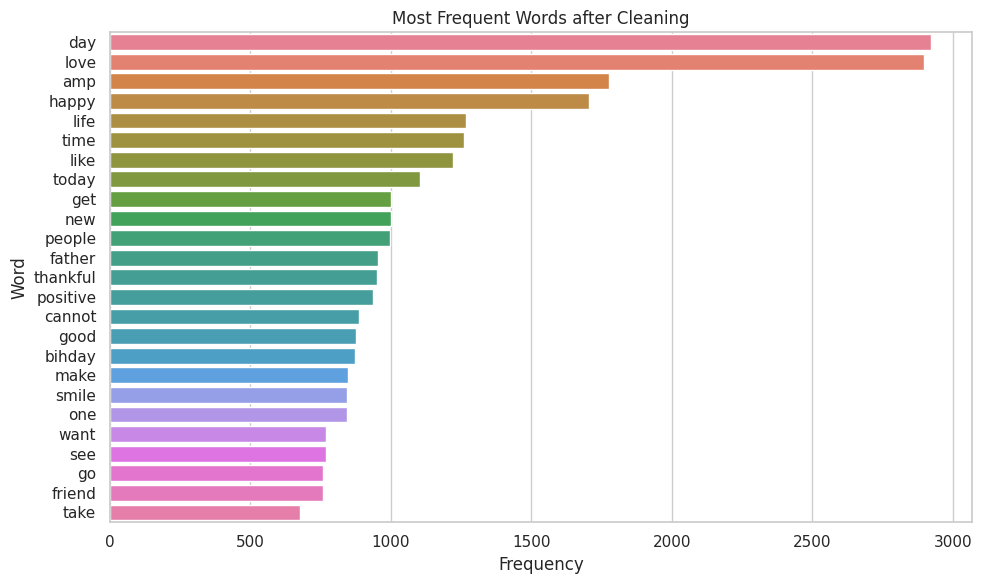

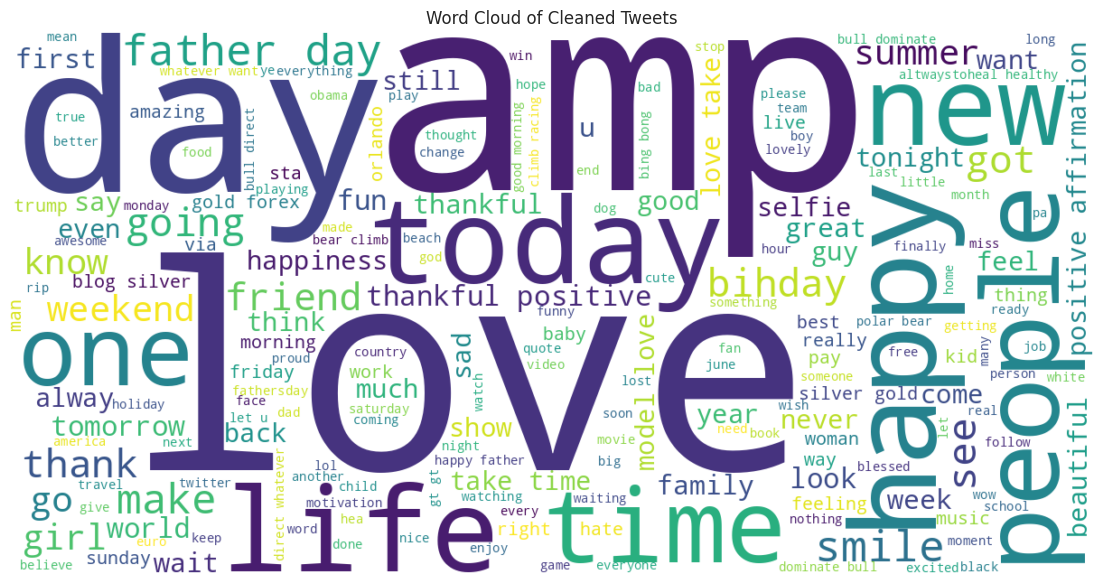

In [ ]:
all_tokens = " ".join(train_df["clean_tweet"]).split()
token_counts = Counter(all_tokens)
top_words = pd.DataFrame(token_counts.most_common(25), columns=["word", "count"])
display(top_words)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_words, y="word", x="count", hue="word", dodge=False)
ax.set_title("Most Frequent Words after Cleaning")
ax.set_xlabel("Frequency")
ax.set_ylabel("Word")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_words.png", dpi=160)
plt.show()

wordcloud = WordCloud(width=1200, height=600, background_color="white", colormap="viridis").generate(
    " ".join(train_df["clean_tweet"])
)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Tweets")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "wordcloud_all_tweets.png", dpi=160)
plt.show()

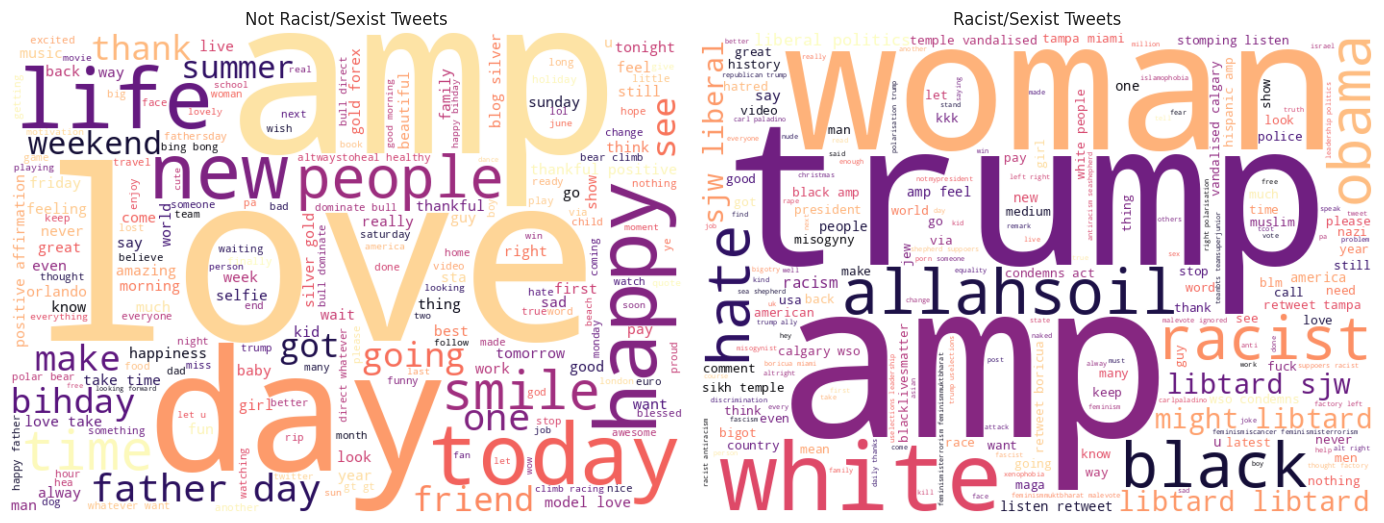

In [ ]:
positive_text = " ".join(train_df.loc[train_df["label"] == 1, "clean_tweet"])
negative_text = " ".join(train_df.loc[train_df["label"] == 0, "clean_tweet"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, text, title in [
    (axes[0], negative_text, "Not Racist/Sexist Tweets"),
    (axes[1], positive_text, "Racist/Sexist Tweets"),
]:
    cloud = WordCloud(width=700, height=500, background_color="white", colormap="magma").generate(text)
    ax.imshow(cloud, interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "wordcloud_by_class.png", dpi=160)
plt.show()

## 4. Train/Test Split, Tokenization, and Padding

The labelled training data is split into 80% training data and 20% held-out test data using stratification. This keeps the minority racist/sexist class proportion almost identical in both splits: about 7.02% in training and 7.01% in testing.

Keras `Tokenizer` converts cleaned words into integer sequences. The tokenizer learned 30,428 words, and the model uses the top 20,000 words. The 95th percentile sequence length is 13 tokens, so all tweets are padded or truncated to 13 tokens. This avoids wasting computation on extreme outliers while keeping most tweets intact.

In [ ]:
X = train_df["clean_tweet"].astype(str)
y = train_df["label"].astype(int)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training split:", X_train_text.shape, "Held-out test split:", X_test_text.shape)
print("Training class rate:", y_train.mean().round(4))
print("Held-out test class rate:", y_test.mean().round(4))

Training split: (25569,) Held-out test split: (6393,)
Training class rate: 0.0702
Held-out test class rate: 0.0701


In [ ]:
MAX_VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text)
external_test_sequences = tokenizer.texts_to_sequences(external_test_df["clean_tweet"].astype(str))

sequence_lengths = np.array([len(sequence) for sequence in train_sequences])
MAX_SEQUENCE_LENGTH = int(np.percentile(sequence_lengths, 95))
MAX_SEQUENCE_LENGTH = max(MAX_SEQUENCE_LENGTH, 5)

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
external_test_pad = pad_sequences(
    external_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
)

print("Vocabulary size used:", vocab_size)
print("Total learned vocabulary:", len(tokenizer.word_index))
print("95th percentile sequence length:", MAX_SEQUENCE_LENGTH)
print("X_train_pad:", X_train_pad.shape)
print("X_test_pad:", X_test_pad.shape)

Vocabulary size used: 20000
Total learned vocabulary: 30428
95th percentile sequence length: 13
X_train_pad: (25569, 13)
X_test_pad: (6393, 13)


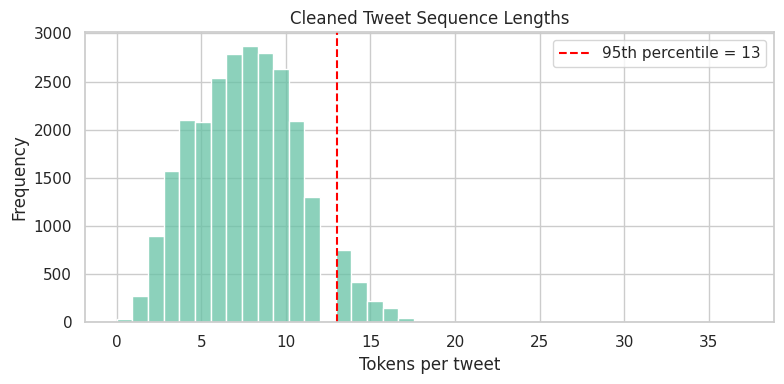

Class weights: {0: np.float64(0.5377287066246057), 1: np.float64(7.1262541806020065)}


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(sequence_lengths, bins=40)
plt.axvline(MAX_SEQUENCE_LENGTH, color="red", linestyle="--", label=f"95th percentile = {MAX_SEQUENCE_LENGTH}")
plt.title("Cleaned Tweet Sequence Lengths")
plt.xlabel("Tokens per tweet")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "sequence_length_distribution.png", dpi=160)
plt.show()

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train,
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

## 5. Helper Functions for Training and Evaluation

All three models use the same padded train/test data, validation split, class weights, callbacks, and evaluation code. Class weighting gives more importance to the minority racist/sexist class. The calculated class weights were approximately 0.54 for class `0` and 7.13 for class `1`, which helps reduce majority-class bias during training.

In [ ]:
BATCH_SIZE = 64
EPOCHS = 10
VALIDATION_SPLIT = 0.10


def make_callbacks(model_name):
    checkpoint_path = MODEL_DIR / f"{model_name}.keras"
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]


def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


def plot_training_history(history, model_name):
    history_df = pd.DataFrame(history.history)
    display(history_df.tail())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["loss"], label="train loss")
    axes[0].plot(history_df["val_loss"], label="validation loss")
    axes[0].set_title(f"{model_name}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].legend()

    axes[1].plot(history_df["accuracy"], label="train accuracy")
    axes[1].plot(history_df["val_accuracy"], label="validation accuracy")
    axes[1].set_title(f"{model_name}: Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_name}_training_curves.png", dpi=160)
    plt.show()


def evaluate_binary_model(model, model_name):
    probabilities = model.predict(X_test_pad, batch_size=BATCH_SIZE).ravel()
    predictions = (probabilities >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    print(f"{model_name} accuracy: {accuracy:.4f}")
    print(f"{model_name} precision for racist/sexist class: {precision:.4f}")
    print(f"{model_name} recall for racist/sexist class: {recall:.4f}")
    print(f"{model_name} F1 for racist/sexist class: {f1:.4f}")
    print()
    print(classification_report(y_test, predictions, target_names=["not_racist_sexist", "racist_sexist"], digits=4))

    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
    )
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"{model_name}_confusion_matrix.png", dpi=160)
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision_positive": precision,
        "recall_positive": recall,
        "f1_positive": f1,
        "probabilities": probabilities,
        "predictions": predictions,
    }

## 6. Model 1: Simple RNN with Trainable Embedding Layer

The Simple RNN model is used as the baseline sequence model. It learns its own word embeddings from the training tweets and then processes the token sequence using a SimpleRNN layer. It trained for 6 epochs before early stopping and restored the best validation-loss weights from epoch 3.

On the held-out test set, the Simple RNN achieved 0.9285 accuracy and a positive-class F1-score of 0.5864. Its recall for racist/sexist tweets was 0.7232, but precision was only 0.4932, showing that it detected many positive examples but also produced a noticeable number of false positives.

In [ ]:
def build_simple_rnn_model():
    model = models.Sequential(
        [
            layers.Embedding(
                input_dim=vocab_size,
                output_dim=64,
                input_length=MAX_SEQUENCE_LENGTH,
                name="trainable_embedding",
            ),
            layers.SimpleRNN(64, dropout=0.20, recurrent_dropout=0.20, name="simple_rnn"),
            layers.Dense(32, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="simple_rnn_trainable_embedding",
    )
    return compile_model(model)


rnn_model = build_simple_rnn_model()
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.6656 - auc: 0.7343 - loss: 0.5981 - precision: 0.1277 - recall: 0.6466 - val_accuracy: 0.9132 - val_auc: 0.9036 - val_loss: 0.2280 - val_precision: 0.4244 - val_recall: 0.6354 - learning_rate: 0.0010
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8920 - auc: 0.9367 - loss: 0.3164 - precision: 0.3814 - recall: 0.8704 - val_accuracy: 0.9308 - val_auc: 0.9100 - val_loss: 0.1963 - val_precision: 0.5084 - val_recall: 0.6685 - learning_rate: 0.0010
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9426 - auc: 0.9767 - loss: 0.1830 - precision: 0.5535 - recall: 0.9392 - val_accuracy: 0.9300 - val_auc: 0.9164 - val_loss: 0.1894 - val_precision: 0.5041 - val_recall: 0.6740 - learning_rate: 0.0010
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9612 - auc: 0.9885 - loss: 0.1260 - precision: 0.6527 - recall: 0.9541 - val_accuracy: 0.9296 - val_auc: 0.8915 - val_loss: 0.2172

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
1,0.891969,0.936672,0.316408,0.381418,0.870428,0.930778,0.910027,0.196286,0.508403,0.668508,0.0010
2,0.942639,0.976652,0.183040,0.553526,0.939244,0.929996,0.916412,0.189382,0.504132,0.674033,0.0010
3,0.961194,0.988526,0.125977,0.652672,0.954123,0.929605,0.891513,0.217156,0.502110,0.657459,0.0010
4,0.968190,0.991624,0.099813,0.694825,0.973962,0.900274,0.889717,0.292934,0.384375,0.679558,0.0010
5,0.977838,0.995717,0.067331,0.767329,0.981401,0.912788,0.905418,0.302029,0.429054,0.701657,0.0005


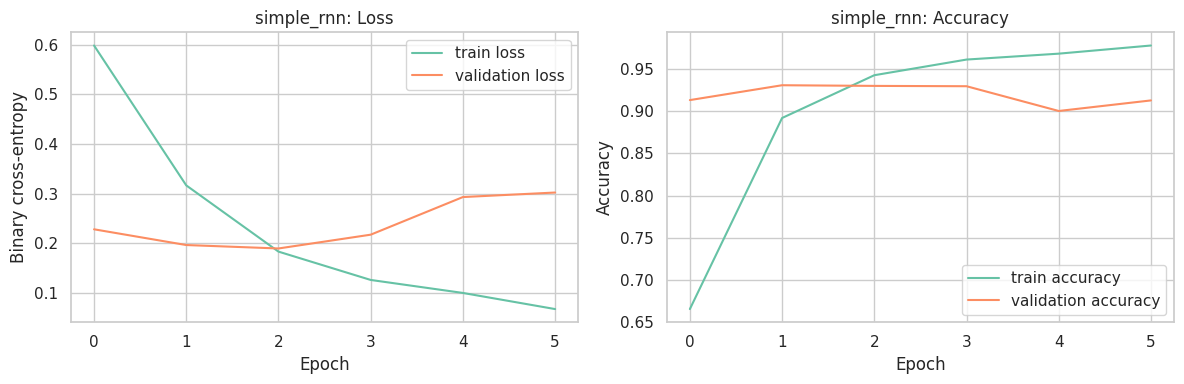

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Simple RNN accuracy: 0.9285
Simple RNN precision for racist/sexist class: 0.4932
Simple RNN recall for racist/sexist class: 0.7232
Simple RNN F1 for racist/sexist class: 0.5864

                   precision    recall  f1-score   support

not_racist_sexist     0.9784    0.9440    0.9609      5945
    racist_sexist     0.4932    0.7232    0.5864       448

         accuracy                         0.9285      6393
        macro avg     0.7358    0.8336    0.7737      6393
     weighted avg     0.9444    0.9285    0.9346      6393



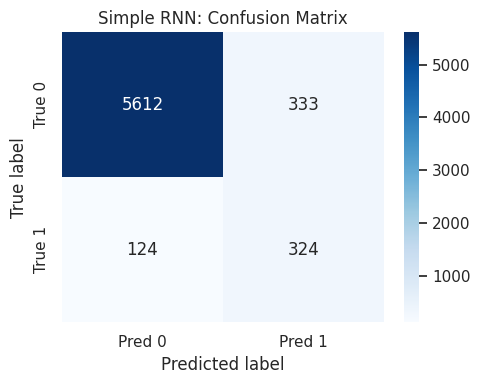

In [ ]:
start_time = time.time()
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("simple_rnn"),
    class_weight=class_weight_dict,
    verbose=1,
)
rnn_training_time = time.time() - start_time
print(f"Simple RNN training time: {rnn_training_time:.2f} seconds")

plot_training_history(rnn_history, "simple_rnn")
rnn_result = evaluate_binary_model(rnn_model, "Simple RNN")
rnn_result["training_time_seconds"] = rnn_training_time

## 7. Model 2: LSTM with Trainable Embedding Layer

The second model replaces the SimpleRNN layer with an LSTM layer. LSTM is better suited to sequence modelling because its gates control what information is remembered or forgotten over time. This model also uses trainable embeddings, spatial dropout, dense layers, and dropout.

The LSTM model trained for 6 epochs and restored the best validation-loss weights from epoch 3. It achieved the best overall result, with 0.9496 accuracy and a positive-class F1-score of 0.6632. Compared with the Simple RNN, the LSTM improved precision from 0.4932 to 0.6240 while keeping recall reasonably high at 0.7076.

In [ ]:
def build_lstm_model():
    model = models.Sequential(
        [
            layers.Embedding(
                input_dim=vocab_size,
                output_dim=128,
                input_length=MAX_SEQUENCE_LENGTH,
                name="trainable_embedding",
            ),
            layers.SpatialDropout1D(0.20),
            layers.LSTM(96, dropout=0.20, recurrent_dropout=0.20, name="lstm"),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.35),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="lstm_trainable_embedding",
    )
    return compile_model(model)


lstm_model = build_lstm_model()
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.8607 - auc: 0.8781 - loss: 0.4335 - precision: 0.2902 - recall: 0.6832 - val_accuracy: 0.9167 - val_auc: 0.9417 - val_loss: 0.2483 - val_precision: 0.4477 - val_recall: 0.7569 - learning_rate: 0.0010
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.9321 - auc: 0.9760 - loss: 0.1960 - precision: 0.5086 - recall: 0.9120 - val_accuracy: 0.9433 - val_auc: 0.9346 - val_loss: 0.1557 - val_precision: 0.5833 - val_recall: 0.6961 - learning_rate: 0.0010
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.9591 - auc: 0.9903 - loss: 0.1157 - precision: 0.6386 - recall: 0.9585 - val_accuracy: 0.9507 - val_auc: 0.9329 - val_loss: 0.1414 - val_precision: 0.6440 - val_recall: 0.6796 - learning_rate: 0.0010
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9763 - auc: 0.9945 - loss: 0.0767 - precision: 0.7581 - recall: 0.9715 - val_accuracy: 0.9542 - val_auc: 0.9143 - val_loss: 0.15

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
1,0.932079,0.976035,0.195952,0.508645,0.911965,0.943293,0.934610,0.155678,0.583333,0.696133,0.0010
2,0.959065,0.990340,0.115746,0.638579,0.958462,0.950724,0.932908,0.141422,0.643979,0.679558,0.0010
3,0.976273,0.994541,0.076704,0.758104,0.971482,0.954243,0.914287,0.155001,0.700000,0.618785,0.0010
4,0.982314,0.997418,0.053441,0.808282,0.980161,0.950332,0.909769,0.185835,0.636364,0.696133,0.0010
5,0.989310,0.998269,0.035551,0.876999,0.985741,0.946422,0.912610,0.205097,0.601852,0.718232,0.0005


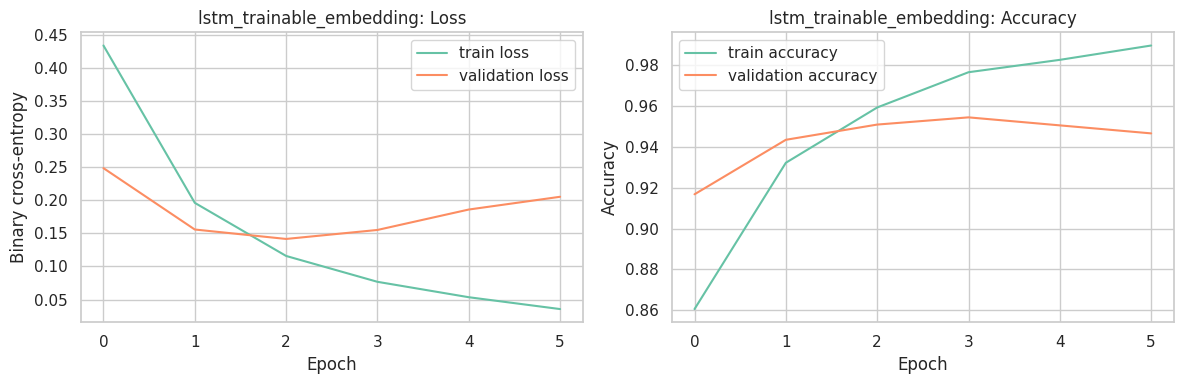

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
LSTM Trainable Embedding accuracy: 0.9496
LSTM Trainable Embedding precision for racist/sexist class: 0.6240
LSTM Trainable Embedding recall for racist/sexist class: 0.7076
LSTM Trainable Embedding F1 for racist/sexist class: 0.6632

                   precision    recall  f1-score   support

not_racist_sexist     0.9777    0.9679    0.9728      5945
    racist_sexist     0.6240    0.7076    0.6632       448

         accuracy                         0.9496      6393
        macro avg     0.8009    0.8377    0.8180      6393
     weighted avg     0.9530    0.9496    0.9511      6393



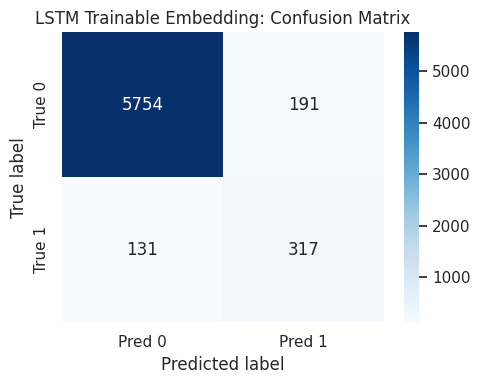

In [ ]:
start_time = time.time()
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("lstm_trainable_embedding"),
    class_weight=class_weight_dict,
    verbose=1,
)
lstm_training_time = time.time() - start_time
print(f"LSTM training time: {lstm_training_time:.2f} seconds")

plot_training_history(lstm_history, "lstm_trainable_embedding")
lstm_result = evaluate_binary_model(lstm_model, "LSTM Trainable Embedding")
lstm_result["training_time_seconds"] = lstm_training_time

## 8. Model 3: LSTM with Pretrained Word Embeddings

The third model uses pretrained `glove-twitter-50` embeddings through `gensim.downloader`. This embedding source is suitable for the task because it was trained on Twitter-style text. The embedding matrix matched 14,689 of the 19,999 usable vocabulary entries, giving 73.45% vocabulary coverage.

This model achieved the highest recall for the racist/sexist class at 0.7924, meaning it found more positive examples than the other models. However, its precision was much lower at 0.3362, and its positive-class F1-score was 0.4721. This suggests that the pretrained embedding model was more aggressive in predicting the positive class and produced many false positives.

In [ ]:
import gensim.downloader as api

PRETRAINED_EMBEDDING_NAME = "glove-twitter-50"

embedding_model = api.load(PRETRAINED_EMBEDDING_NAME)
embedding_dim = embedding_model.vector_size
print("Loaded pretrained embedding:", PRETRAINED_EMBEDDING_NAME)
print("Embedding dimension:", embedding_dim)

[==================================================] 100.0% 199.5/199.5MB downloaded
Loaded pretrained embedding: glove-twitter-50
Embedding dimension: 50


In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
matched_words = 0

for word, index in tokenizer.word_index.items():
    if index >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
        matched_words += 1

coverage = matched_words / max(1, vocab_size - 1)
print(f"Matched words: {matched_words} / {vocab_size - 1}")
print(f"Embedding vocabulary coverage: {coverage:.2%}")

Matched words: 14689 / 19999
Embedding vocabulary coverage: 73.45%


In [ ]:
def build_pretrained_lstm_model(trainable_embedding=False):
    model = models.Sequential(
        [
            layers.Embedding(
                input_dim=vocab_size,
                output_dim=embedding_dim,
                weights=[embedding_matrix],
                input_length=MAX_SEQUENCE_LENGTH,
                trainable=trainable_embedding,
                name="pretrained_glove_twitter_embedding",
            ),
            layers.SpatialDropout1D(0.20),
            layers.LSTM(96, dropout=0.20, recurrent_dropout=0.20, name="lstm"),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.35),
            layers.Dense(1, activation="sigmoid"),
        ],
        name="lstm_pretrained_embedding",
    )
    return compile_model(model)


pretrained_lstm_model = build_pretrained_lstm_model(trainable_embedding=False)
pretrained_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_pretrained_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_glove_twitter_embed… │ ?                      │     1,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.7785 - auc: 0.8530 - loss: 0.4807 - precision: 0.2101 - recall: 0.7830 - val_accuracy: 0.8463 - val_auc: 0.9063 - val_loss: 0.3727 - val_precision: 0.2888 - val_recall: 0.8011 - learning_rate: 0.0010
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8057 - auc: 0.8869 - loss: 0.4248 - precision: 0.2403 - recall: 0.8196 - val_accuracy: 0.8553 - val_auc: 0.9137 - val_loss: 0.3650 - val_precision: 0.3052 - val_recall: 0.8177 - learning_rate: 0.0010
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.8102 - auc: 0.8984 - loss: 0.4031 - precision: 0.2466 - recall: 0.8308 - val_accuracy: 0.8768 - val_auc: 0.9217 - val_loss: 0.3061 - val_precision: 0.3412 - val_recall: 0.7956 - learning_rate: 0.0010
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.8177 - auc: 0.9072 - loss: 0.3876 - precision: 0.2578 - recall: 0.8518 - val_accuracy: 0.8745 - val_auc: 0.9296 - val_loss: 0.27

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
2,0.810229,0.898438,0.403118,0.246596,0.830750,0.876809,0.921743,0.306114,0.341232,0.795580,0.0010
3,0.817704,0.907191,0.387568,0.257786,0.851829,0.874462,0.929648,0.278603,0.336449,0.795580,0.0010
4,0.820181,0.915973,0.367871,0.260573,0.851829,0.876418,0.932749,0.290244,0.340426,0.795580,0.0010
5,0.833782,0.922531,0.354548,0.278001,0.858648,0.865467,0.933294,0.278833,0.320879,0.806630,0.0010
6,0.838649,0.928011,0.341572,0.284836,0.861748,0.839265,0.937169,0.330374,0.291667,0.889503,0.0005


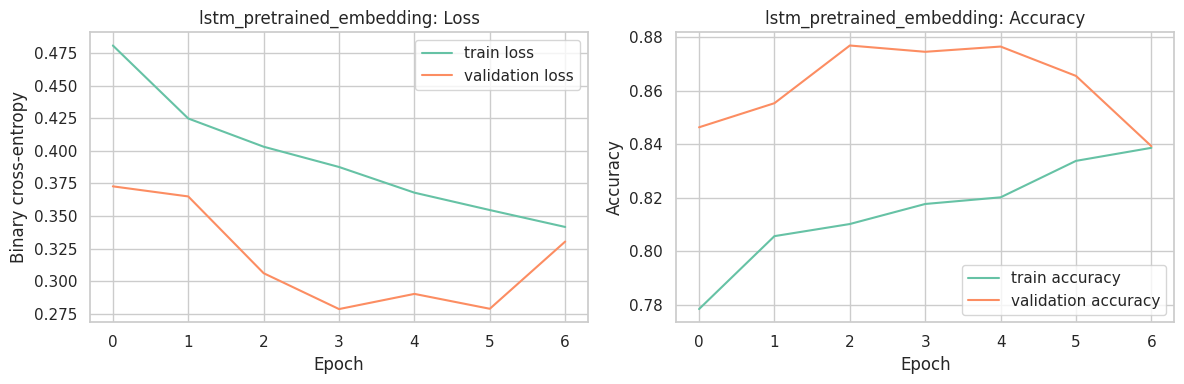

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
LSTM Pretrained Embedding accuracy: 0.8758
LSTM Pretrained Embedding precision for racist/sexist class: 0.3362
LSTM Pretrained Embedding recall for racist/sexist class: 0.7924
LSTM Pretrained Embedding F1 for racist/sexist class: 0.4721

                   precision    recall  f1-score   support

not_racist_sexist     0.9826    0.8821    0.9296      5945
    racist_sexist     0.3362    0.7924    0.4721       448

         accuracy                         0.8758      6393
        macro avg     0.6594    0.8372    0.7008      6393
     weighted avg     0.9373    0.8758    0.8976      6393



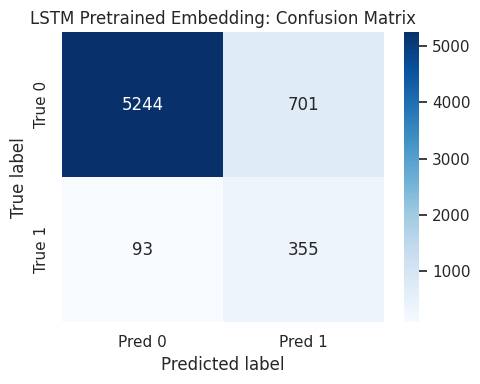

In [ ]:
start_time = time.time()
pretrained_lstm_history = pretrained_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks("lstm_pretrained_embedding"),
    class_weight=class_weight_dict,
    verbose=1,
)
pretrained_lstm_training_time = time.time() - start_time
print(f"Pretrained LSTM training time: {pretrained_lstm_training_time:.2f} seconds")

plot_training_history(pretrained_lstm_history, "lstm_pretrained_embedding")
pretrained_lstm_result = evaluate_binary_model(pretrained_lstm_model, "LSTM Pretrained Embedding")
pretrained_lstm_result["training_time_seconds"] = pretrained_lstm_training_time

## 9. Model Comparison

The model comparison shows that the LSTM with trainable embeddings is the best model for this experiment. It achieved the highest accuracy (0.9496), highest precision for the racist/sexist class (0.6240), and highest positive-class F1-score (0.6632). The Simple RNN was faster, but less accurate and less precise. The pretrained LSTM had the highest recall but the lowest F1-score because of its high false-positive rate.

For this dataset, the trainable LSTM is the most balanced choice. It does not maximise recall, but it gives the best trade-off between detecting racist/sexist tweets and avoiding incorrect flags.

,model,accuracy,precision_positive,recall_positive,f1_positive,training_time_seconds
1,LSTM Trainable Embedding,0.9496,0.6240,0.7076,0.6632,147.5882
0,Simple RNN,0.9285,0.4932,0.7232,0.5864,53.1441
2,LSTM Pretrained Embedding,0.8758,0.3362,0.7924,0.4721,97.0588


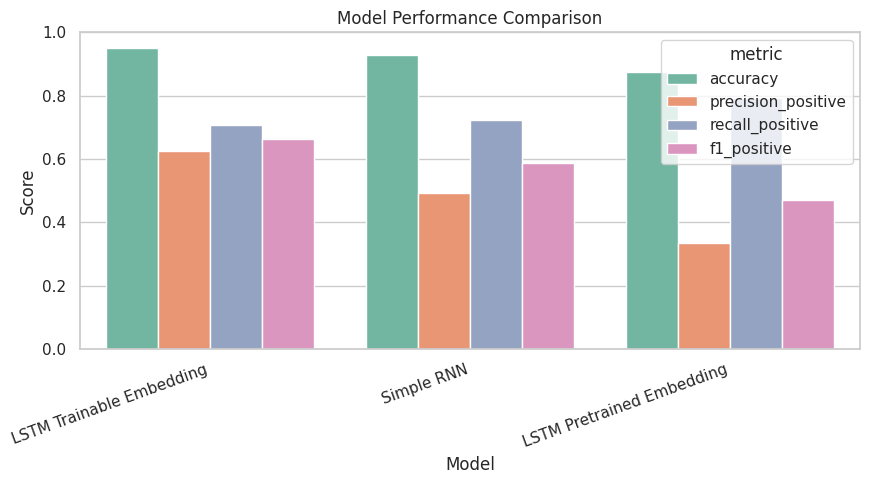

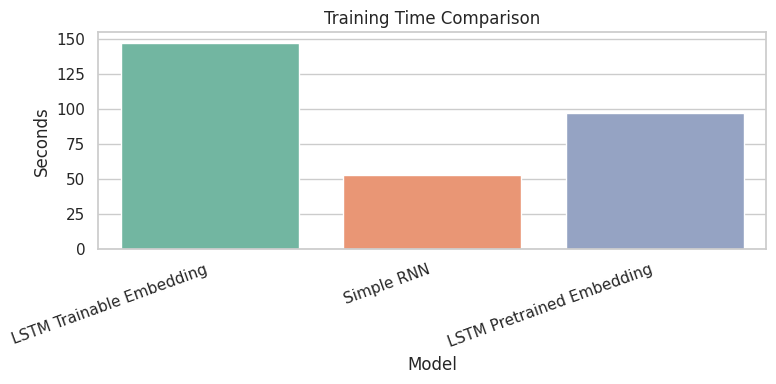

In [ ]:
model_results = [rnn_result, lstm_result, pretrained_lstm_result]

results_df = pd.DataFrame(
    [
        {
            "model": result["model"],
            "accuracy": result["accuracy"],
            "precision_positive": result["precision_positive"],
            "recall_positive": result["recall_positive"],
            "f1_positive": result["f1_positive"],
            "training_time_seconds": result["training_time_seconds"],
        }
        for result in model_results
    ]
).sort_values("f1_positive", ascending=False)

display(results_df.round(4))
results_df.to_csv(OUTPUT_DIR / "model_comparison_results.csv", index=False)

plt.figure(figsize=(9, 5))
comparison_long = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision_positive", "recall_positive", "f1_positive"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=comparison_long, x="model", y="score", hue="metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_comparison_metrics.png", dpi=160)
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="training_time_seconds", hue="model")
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "model_training_time_comparison.png", dpi=160)
plt.show()

## 10. Error Analysis

The best model by positive-class F1-score is the LSTM with trainable embeddings. It produced 322 misclassified examples on the held-out test set. The error table shows both false positives and false negatives.

False positives often contain strong terms such as `hatred`, `attack`, `black men`, `immigrants`, or political hashtags. These terms can appear in non-hateful discussion but still look risky to the model. False negatives include short or hashtag-heavy tweets where the harmful meaning may be indirect or dependent on context.

In [ ]:
model_objects = {
    "Simple RNN": rnn_model,
    "LSTM Trainable Embedding": lstm_model,
    "LSTM Pretrained Embedding": pretrained_lstm_model,
}

best_model_name = results_df.iloc[0]["model"]
best_model = model_objects[best_model_name]
print("Best model by positive-class F1:", best_model_name)

best_probabilities = best_model.predict(X_test_pad, batch_size=BATCH_SIZE).ravel()
best_predictions = (best_probabilities >= 0.5).astype(int)

error_df = pd.DataFrame(
    {
        "tweet": train_df.loc[X_test_text.index, "tweet"].values,
        "clean_tweet": X_test_text.values,
        "true_label": y_test.values,
        "predicted_label": best_predictions,
        "probability_racist_sexist": best_probabilities,
    }
)
error_df["error_type"] = np.where(
    (error_df["true_label"] == 0) & (error_df["predicted_label"] == 1),
    "false_positive",
    np.where(
        (error_df["true_label"] == 1) & (error_df["predicted_label"] == 0),
        "false_negative",
        "correct",
    ),
)

misclassified_df = error_df[error_df["error_type"] != "correct"].copy()
print("Total misclassified examples:", len(misclassified_df))

display(
    misclassified_df.sort_values("probability_racist_sexist", ascending=False)
    .groupby("error_type")
    .head(3)
)

misclassified_df.to_csv(OUTPUT_DIR / "misclassified_examples.csv", index=False)

Best model by positive-class F1: LSTM Trainable Embedding
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Total misclassified examples: 322


,tweet,clean_tweet,true_label,predicted_label,probability_racist_sexist,error_type
3692,"you tell versions of lies, @user with your hatred and vile attacks upon black men and women, theron. @user @user",tell version lie hatred vile attack upon black men woman theron,0,1,0.993845,false_positive
3624,@user our global media platform would very much like to suppo you.. #roku tv #mainstreammedia won't,global medium platform would much like suppo roku tv mainstreammedia,0,1,0.992918,false_positive
6022,we all legal #immigrants at some point. &amp; thats the whole point #legal it's @user @user promote usa destruction,legal immigrant point amp whole point legal promote usa destruction,0,1,0.992276,false_positive
4469,#nycÂ #assault Â #womenonly #forher #2017 #newyears #resolution #womenissuesÂ - self defense for women course,nyc assault womenonly forher newyears resolution womenissues self defense woman course,1,0,0.493651,false_negative
1992,next attack wont be in japan. guaranteed. #smaimmigration #zeroattacks #istanbul #religionofpeace #reliability,next attack japan guaranteed smaimmigration zeroattacks istanbul religionofpeace reliability,1,0,0.493263,false_negative
2962,@user thats you #liberals!,liberal,1,0,0.492159,false_negative


### Error Analysis Notes

The false-positive examples show that the model can overreact to sensitive vocabulary even when a tweet may be discussing a topic rather than expressing racist or sexist sentiment. The false-negative examples show the opposite issue: tweets with limited context, indirect language, or compressed hashtag meaning may be missed.

This is why a model like this should support human moderation rather than act as a fully automatic decision system. For harmful-content detection, both false negatives and false positives have practical consequences.

## 11. Final Predictions for the Provided Unlabelled Test File

The external `test_racisit.csv` file has no labels, so it cannot be used for performance evaluation. The best model was used only to generate predictions for this file. Out of 17,197 external tweets, the model predicted 15,822 as not racist/sexist and 1,375 as racist/sexist.

In [ ]:
external_probabilities = best_model.predict(external_test_pad, batch_size=BATCH_SIZE).ravel()
external_predictions = (external_probabilities >= 0.5).astype(int)

prediction_df = external_test_df[["id", "tweet"]].copy()
prediction_df["clean_tweet"] = external_test_df["clean_tweet"]
prediction_df["predicted_label"] = external_predictions
prediction_df["probability_racist_sexist"] = external_probabilities

prediction_path = OUTPUT_DIR / "external_test_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)

print("Saved external test predictions to:", prediction_path)
display(prediction_df.head())
display(prediction_df["predicted_label"].value_counts().rename_axis("predicted_label").reset_index(name="count"))

269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Saved external test predictions to: /content/drive/MyDrive/AI&ML/NLP Task/portfolio_outputs/nlp_hate_speech/external_test_predictions.csv


,id,tweet,clean_tweet,predicted_label,probability_racist_sexist
0,31963,#studiolife #aislife #requires #passion #dedication #willpower to find #newmaterialsâ¦,studiolife aislife requires passion dedication willpower find newmaterials,0,0.267531
1,31964,@user #white #supremacists want everyone to see the new â #birdsâ #movie â and hereâs why,white supremacist want everyone see new bird movie,1,0.949180
2,31965,safe ways to heal your #acne!! #altwaystoheal #healthy #healing!!,safe way heal acne altwaystoheal healthy healing,0,0.003202
3,31966,"is the hp and the cursed child book up for reservations already? if yes, where? if no, when? ððð #harrypotter #pottermore #favorite",hp cursed child book reservation already yes harrypotter pottermore favorite,0,0.051404
4,31967,"3rd #bihday to my amazing, hilarious #nephew eli ahmir! uncle dave loves you and missesâ¦",rd bihday amazing hilarious nephew eli ahmir uncle dave love miss,0,0.001783


,predicted_label,count
0,0,15822
1,1,1375


## 12. Conclusion

This notebook completed the NLP task by building and comparing three recurrent text-classification models for racist/sexist tweet detection. The dataset was highly imbalanced, with only 7.01% of labelled tweets belonging to the positive class, so precision, recall, F1-score, and confusion matrices were used alongside accuracy.

The LSTM with trainable embeddings performed best overall, achieving 0.9496 accuracy and 0.6632 F1-score for the racist/sexist class. The Simple RNN was faster but less precise, while the pretrained-embedding LSTM achieved the highest recall but produced too many false positives. The final model is useful as an experimental classifier, but limitations remain because tweets are short, informal, context-dependent, and socially sensitive. Future work should consider threshold tuning, more balanced data, transformer-based models, and fairness testing.